In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv', encoding='unicode_escape')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
print(df.columns.tolist())
print(df.shape)

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
(541909, 8)


In [3]:
##  Checking for missing values

print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
##   Checking data types

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [5]:
##   Checking basic statistics

print(df.describe())

            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


In [6]:
## cleaning the data

In [7]:
##  Removeing cancelled orders

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(df.shape)

(532621, 8)


In [8]:
##  Removeing negative quantities and prices

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print(df.shape)

(530104, 8)


In [9]:
##  Drop missing CustomerID and Description

df = df.dropna(subset=['CustomerID', 'Description'])
print(df.shape)

(397884, 8)


In [10]:
##  Convert InvoiceDate to proper date format

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year
print(df['InvoiceDate'].head())

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]


In [11]:
##  Createing Total Revenue column

df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']
print(df['TotalRevenue'].head())

0    15.30
1    20.34
2    22.00
3    20.34
4    20.34
Name: TotalRevenue, dtype: float64


In [12]:
##  Confirm everything is clean

print(df.isnull().sum())
print(df.shape)

InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
Month           0
Year            0
TotalRevenue    0
dtype: int64
(397884, 11)


In [13]:
## analyzing the data



In [14]:
##  Total overall revenue

total_revenue = df['TotalRevenue'].sum()
print(f'Total Revenue: ${total_revenue:,.2f}')

Total Revenue: $8,911,407.90


In [15]:
##   Top 10 countries by revenue

top_countries = df.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False).head(10)
print(top_countries)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalRevenue, dtype: float64


In [16]:
##  Top 10 best selling products

top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [17]:
##  Monthly revenue trend

monthly_revenue = df.groupby(['Year', 'Month'])['TotalRevenue'].sum()
print(monthly_revenue)

Year  Month
2010  12        572713.890
2011  1         569445.040
      2         447137.350
      3         595500.760
      4         469200.361
      5         678594.560
      6         661213.690
      7         600091.011
      8         645343.900
      9         952838.382
      10       1039318.790
      11       1161817.380
      12        518192.790
Name: TotalRevenue, dtype: float64


In [18]:
##   Top 10 customers by revenue

top_customers = df.groupby('CustomerID')['TotalRevenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalRevenue, dtype: float64


In [19]:
## Average order value

avg_order = df.groupby('InvoiceNo')['TotalRevenue'].sum().mean()
print(f'Average Order Value: ${avg_order:,.2f}')

Average Order Value: $480.87


In [20]:
## Visualization

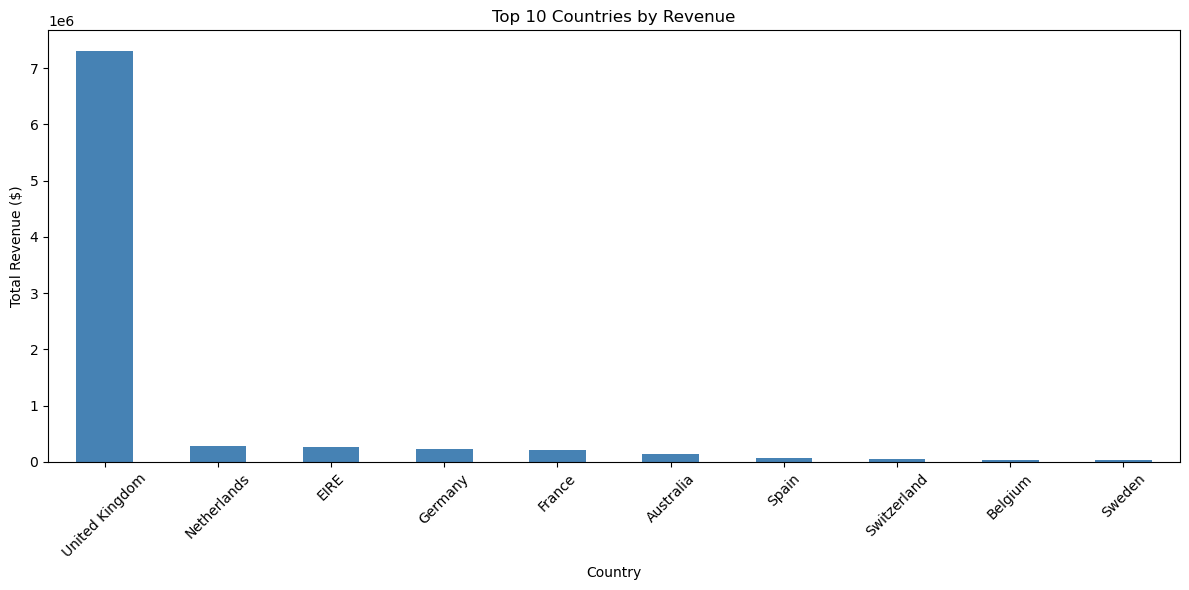

In [21]:
##   Top 10 Countries by Revenue (Bar Chart)

plt.figure(figsize=(12,6))
top_countries.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

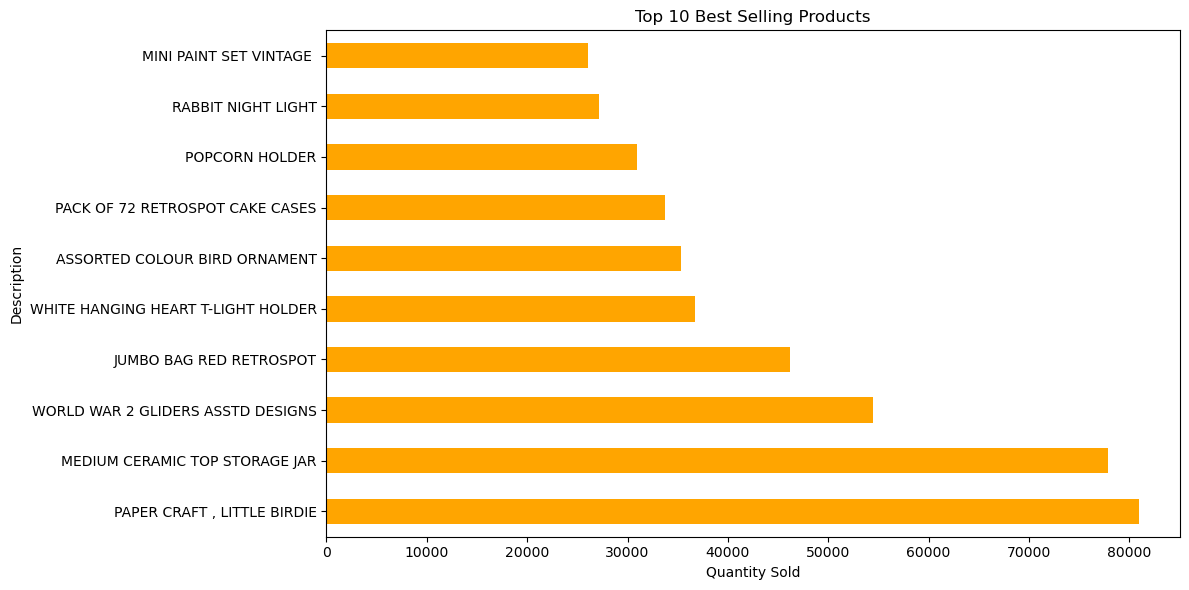

In [22]:
##  Top 10 Best Selling Products (Bar Chart)

plt.figure(figsize=(12,6))
top_products.plot(kind='barh', color='orange')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Quantity Sold')
plt.tight_layout()
plt.show()

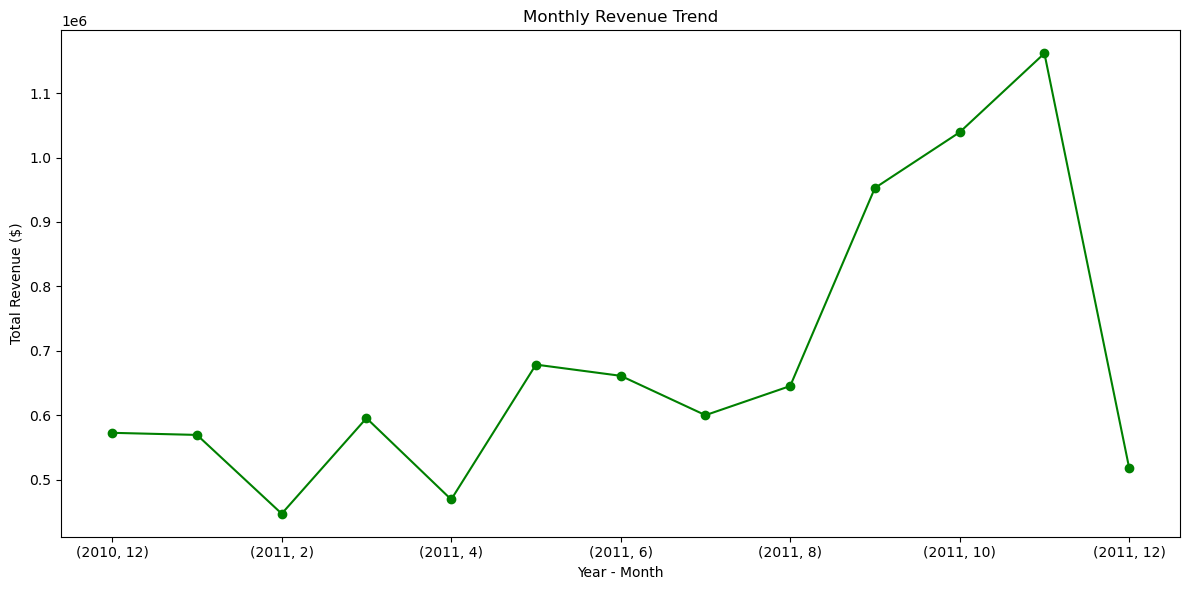

In [23]:
##  Monthly Revenue Trend (Line Chart)

plt.figure(figsize=(12,6))
monthly_revenue.plot(kind='line', color='green', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Year - Month')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

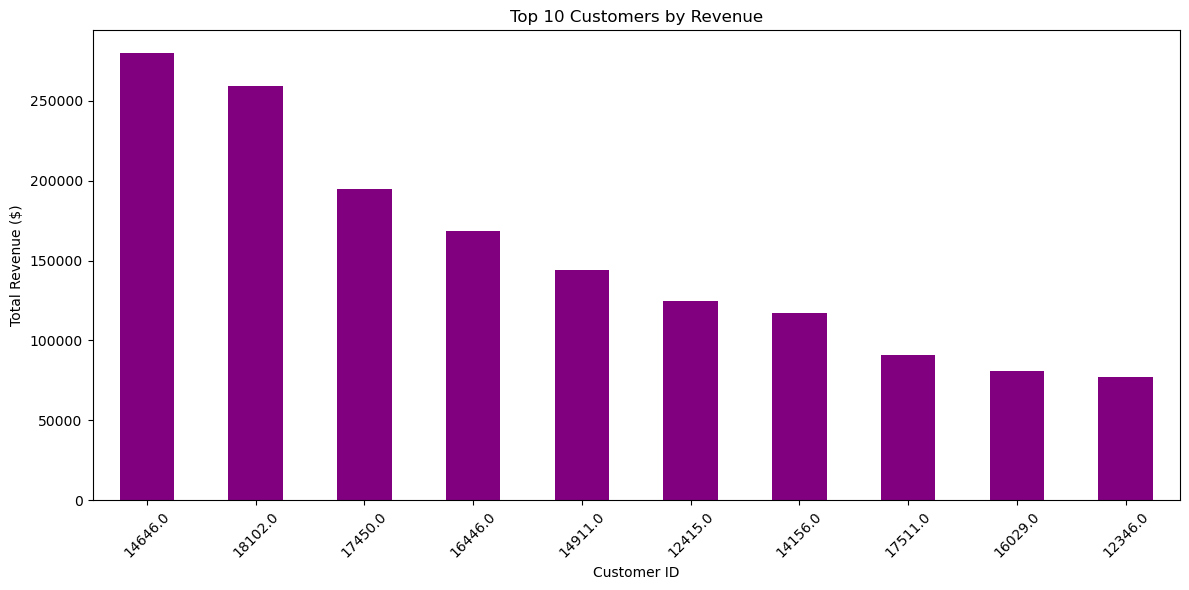

In [24]:
##  Top 10 Customers by Revenue (Bar Chart)

plt.figure(figsize=(12,6))
top_customers.plot(kind='bar', color='purple')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
df.to_csv('ecommerce_cleaned.csv', index=False)
print('File saved successfully')

File saved successfully


In [26]:
df_sample = df.sample(n=10000, random_state=42)
df_sample.to_csv('ecommerce_sample.csv', index=False)
print('Sample file saved')

Sample file saved


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('data.csv', encoding='unicode_escape')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df = df.dropna(subset=['CustomerID', 'Description'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year
df['Hour'] = df['InvoiceDate'].dt.hour
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']
print('Data loaded successfully')
print(df.shape)

Data loaded successfully
(397884, 12)


In [28]:
##  Adding to the analysis

In [29]:
##  RFM Analysis

import datetime
snapshot_date = df['InvoiceDate'].max() + datetime.timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalRevenue', 'sum')
).round(2)

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("=== RFM ANALYSIS ===")
print(f"Total Customers: {len(rfm)}")
print(f"Average Recency: {rfm['Recency'].mean():.0f} days")
print(f"Average Frequency: {rfm['Frequency'].mean():.1f} orders")
print(f"Average Monetary: ${rfm['Monetary'].mean():,.2f}")
print("\nTop 10 Most Valuable Customers:")
print(rfm.nlargest(10, 'Monetary')[['Recency', 'Frequency', 'Monetary']].to_string())

=== RFM ANALYSIS ===
Total Customers: 4338
Average Recency: 93 days
Average Frequency: 4.3 orders
Average Monetary: $2,054.27

Top 10 Most Valuable Customers:
            Recency  Frequency   Monetary
CustomerID                               
14646.0           2         73  280206.02
18102.0           1         60  259657.30
17450.0           8         46  194550.79
16446.0           1          2  168472.50
14911.0           1        201  143825.06
12415.0          24         21  124914.53
14156.0          10         55  117379.63
17511.0           3         31   91062.38
16029.0          39         63   81024.84
12346.0         326          1   77183.60


In [30]:
##  Customer Lifetime Value

clv = df.groupby('CustomerID').agg(
    Total_Revenue=('TotalRevenue', 'sum'),
    Total_Orders=('InvoiceNo', 'nunique'),
    Avg_Order_Value=('TotalRevenue', 'mean')
).round(2)

print("=== CUSTOMER LIFETIME VALUE ===")
print(f"Average Customer Lifetime Value: ${clv['Total_Revenue'].mean():,.2f}")
print(f"Highest CLV: ${clv['Total_Revenue'].max():,.2f}")
print(f"Average Orders per Customer: {clv['Total_Orders'].mean():.1f}")
print("\nTop 10 Customers by CLV:")
print(clv.nlargest(10, 'Total_Revenue').to_string())

=== CUSTOMER LIFETIME VALUE ===
Average Customer Lifetime Value: $2,054.27
Highest CLV: $280,206.02
Average Orders per Customer: 4.3

Top 10 Customers by CLV:
            Total_Revenue  Total_Orders  Avg_Order_Value
CustomerID                                              
14646.0         280206.02            73           134.97
18102.0         259657.30            60           602.45
17450.0         194550.79            46           577.30
16446.0         168472.50             2         56157.50
14911.0         143825.06           201            25.34
12415.0         124914.53            21           174.95
14156.0         117379.63            55            83.84
17511.0          91062.38            31            94.56
16029.0          81024.84            63           334.81
12346.0          77183.60             1         77183.60


In [31]:
##   Hourly Sales Pattern

hourly_sales = df.groupby('Hour')['TotalRevenue'].sum()
print("=== HOURLY SALES PATTERN ===")
print(hourly_sales)
print(f"\nPeak Sales Hour: {hourly_sales.idxmax()}:00")
print(f"Lowest Sales Hour: {hourly_sales.idxmin()}:00")

=== HOURLY SALES PATTERN ===
Hour
6           4.250
7       31059.210
8      282115.630
9      842605.171
10    1261192.571
11    1104558.750
12    1378571.480
13    1173264.750
14     995629.371
15     966191.750
16     468885.800
17     234413.521
18     104954.430
19      49028.460
20      18932.760
Name: TotalRevenue, dtype: float64

Peak Sales Hour: 12:00
Lowest Sales Hour: 6:00


In [32]:
##  Basket Size Analysis

basket = df.groupby('InvoiceNo').agg(
    Items=('Quantity', 'sum'),
    Revenue=('TotalRevenue', 'sum')
).round(2)
print("=== BASKET SIZE ANALYSIS ===")
print(f"Average Items per Order: {basket['Items'].mean():.1f}")
print(f"Average Order Value: ${basket['Revenue'].mean():,.2f}")
print(f"Largest Order: {basket['Items'].max():.0f} items")

=== BASKET SIZE ANALYSIS ===
Average Items per Order: 278.9
Average Order Value: $480.87
Largest Order: 80995 items


In [33]:
##  Country Market Share

country_share = df.groupby('Country')['TotalRevenue'].sum()
country_share_pct = (country_share / country_share.sum() * 100).round(2)
print("=== COUNTRY MARKET SHARE ===")
print(country_share_pct.sort_values(ascending=False).head(10))

=== COUNTRY MARKET SHARE ===
Country
United Kingdom    82.01
Netherlands        3.20
EIRE               2.98
Germany            2.57
France             2.35
Australia          1.55
Spain              0.69
Switzerland        0.63
Belgium            0.46
Sweden             0.43
Name: TotalRevenue, dtype: float64


In [34]:
##   Monthly Revenue Trend

monthly_revenue = df.groupby(['Year', 'Month'])['TotalRevenue'].sum().reset_index()
print("=== MONTHLY REVENUE TREND ===")
print(monthly_revenue.to_string())

=== MONTHLY REVENUE TREND ===
    Year  Month  TotalRevenue
0   2010     12    572713.890
1   2011      1    569445.040
2   2011      2    447137.350
3   2011      3    595500.760
4   2011      4    469200.361
5   2011      5    678594.560
6   2011      6    661213.690
7   2011      7    600091.011
8   2011      8    645343.900
9   2011      9    952838.382
10  2011     10   1039318.790
11  2011     11   1161817.380
12  2011     12    518192.790


In [35]:
## Adding to the visualization

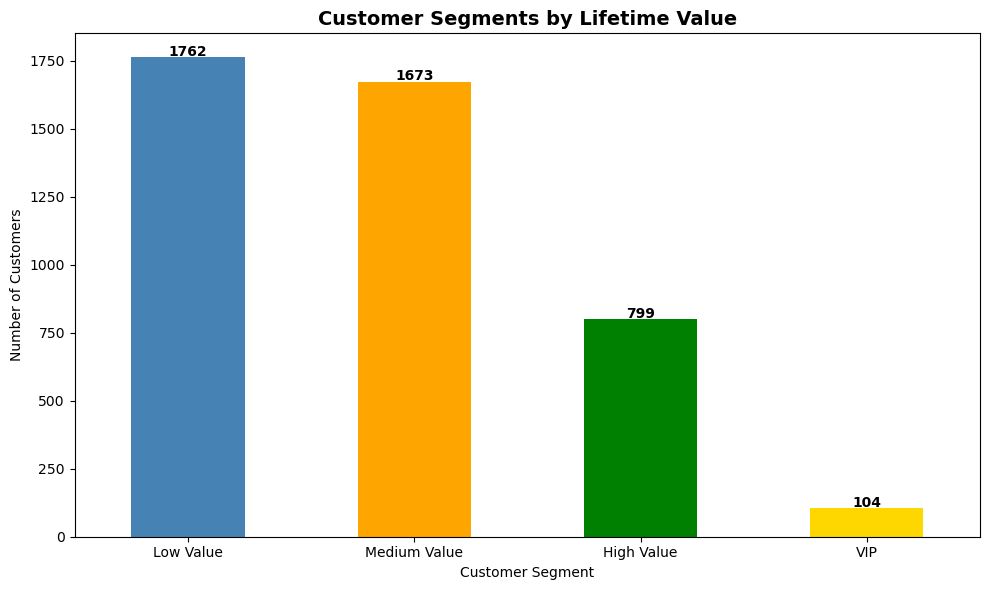

In [36]:
##   RFM Customer Segments

rfm_segments = pd.cut(rfm['Monetary'],
    bins=[0, 500, 2000, 10000, float('inf')],
    labels=['Low Value', 'Medium Value', 'High Value', 'VIP'])
segment_counts = rfm_segments.value_counts()
plt.figure(figsize=(10,6))
segment_counts.plot(kind='bar', color=['steelblue', 'orange', 'green', 'gold'])
plt.title('Customer Segments by Lifetime Value', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
for i, v in enumerate(segment_counts):
    plt.text(i, v+5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

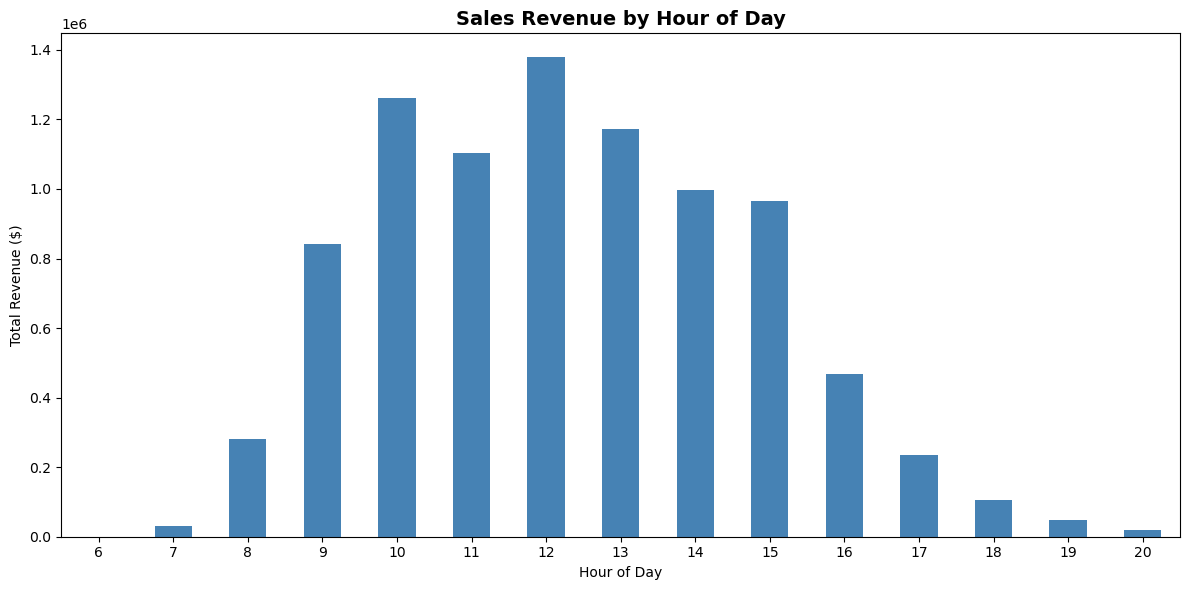

In [37]:
##  Hourly Sales Pattern

plt.figure(figsize=(12,6))
hourly_sales.plot(kind='bar', color='steelblue')
plt.title('Sales Revenue by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

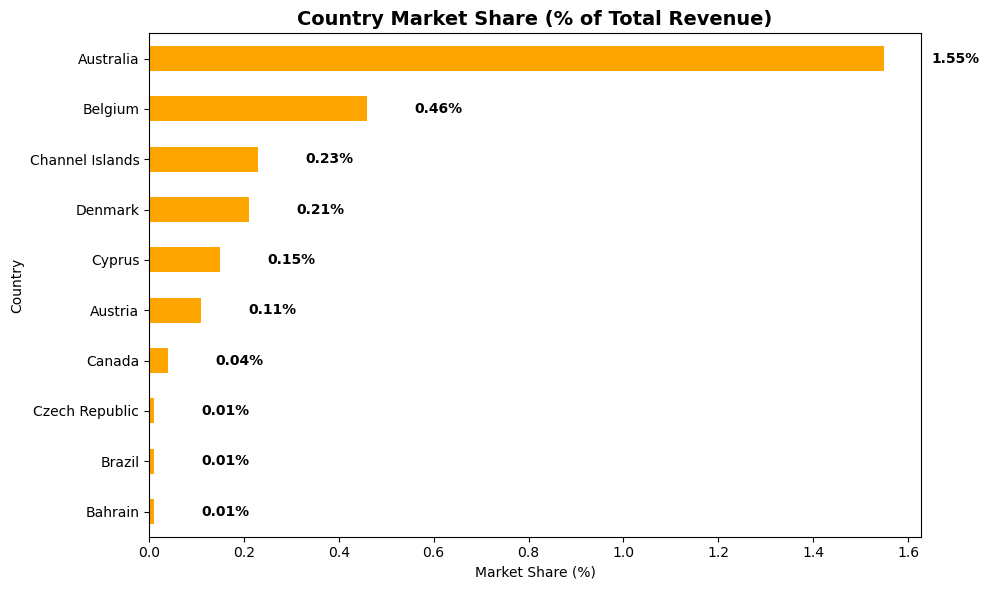

In [38]:
##   Country Market Share

plt.figure(figsize=(10,6))
country_share_pct.head(10).sort_values().plot(kind='barh', color='orange')
plt.title('Country Market Share (% of Total Revenue)', fontsize=14, fontweight='bold')
plt.xlabel('Market Share (%)')
for i, v in enumerate(country_share_pct.head(10).sort_values()):
    plt.text(v+0.1, i, f'{v}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

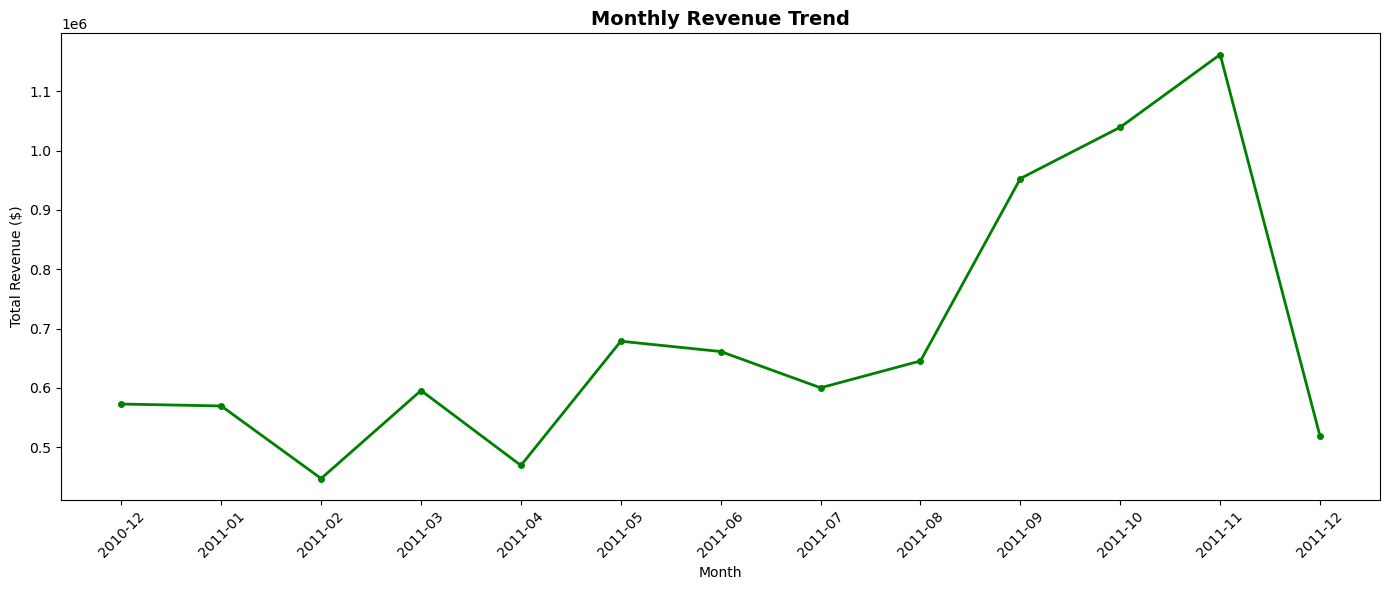

In [40]:
##   Monthly Revenue Trend

plt.figure(figsize=(14,6))
plt.plot(range(len(monthly_revenue)), monthly_revenue['TotalRevenue'], 
         color='green', linewidth=2, marker='o', markersize=4)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
month_labels = [f"{int(row['Year'])}-{int(row['Month']):02d}" for _, row in monthly_revenue.iterrows()]
plt.xticks(range(len(monthly_revenue)), month_labels, rotation=45)
plt.tight_layout()
plt.show()

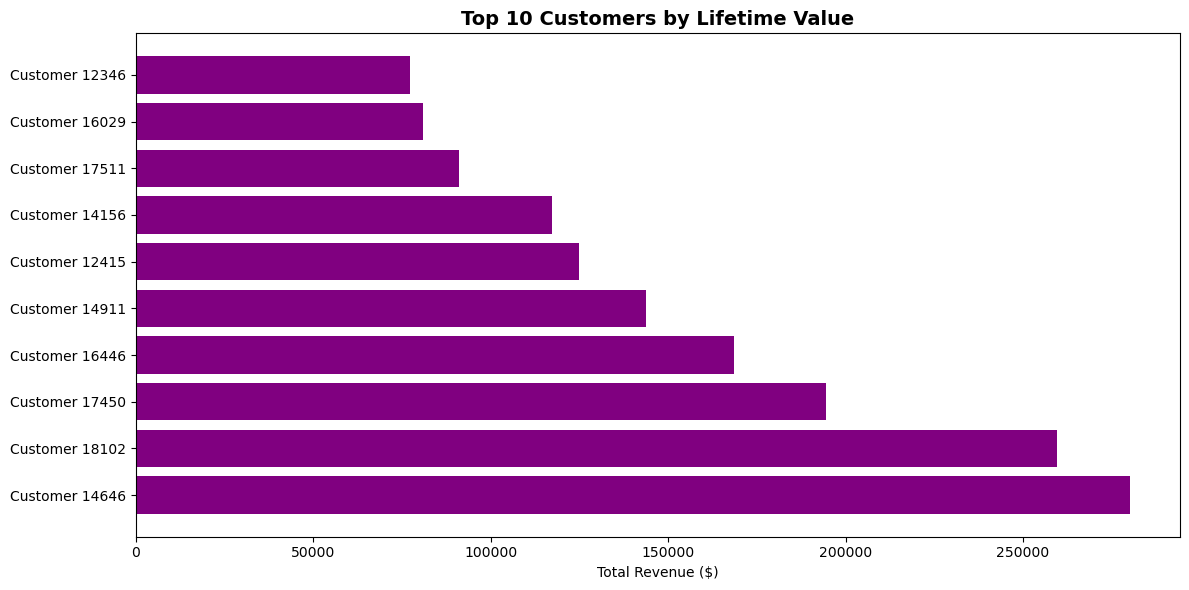

In [41]:
##   Top 10 Customers by CLV

top_clv = clv.nlargest(10, 'Total_Revenue')
plt.figure(figsize=(12,6))
plt.barh(range(len(top_clv)), top_clv['Total_Revenue'], color='purple')
plt.title('Top 10 Customers by Lifetime Value', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)')
plt.yticks(range(len(top_clv)), [f'Customer {int(x)}' for x in top_clv.index])
plt.tight_layout()
plt.show()

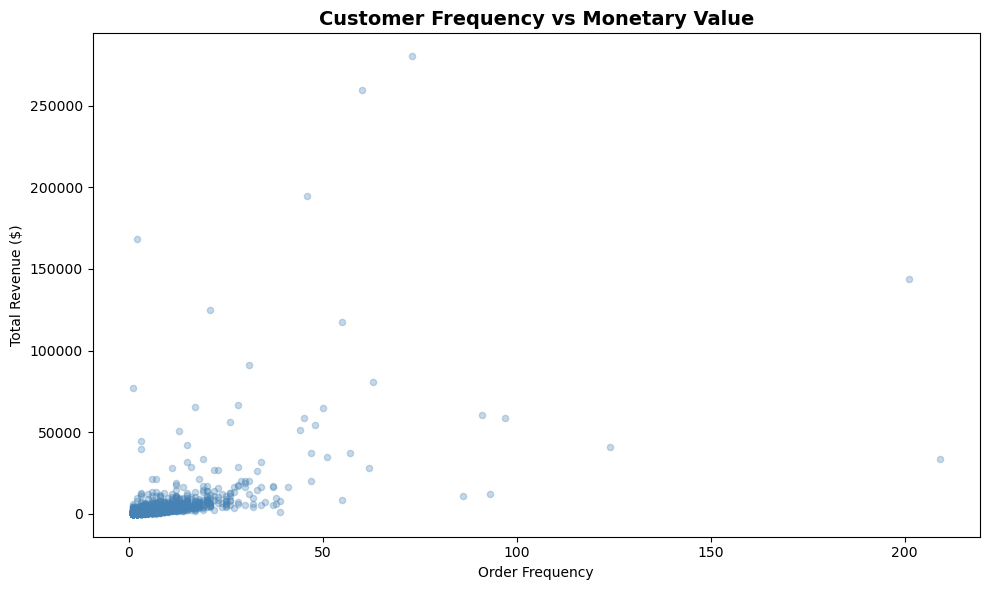

In [42]:
##   RFM Scatter Plot

plt.figure(figsize=(10,6))
plt.scatter(rfm['Frequency'], rfm['Monetary'], 
            alpha=0.3, color='steelblue', s=20)
plt.title('Customer Frequency vs Monetary Value', fontsize=14, fontweight='bold')
plt.xlabel('Order Frequency')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

In [44]:
df.to_csv('ecommerce_sample.csv', index=False)
print('File saved successfully')

File saved successfully
